In [115]:
import numpy as np
import matplotlib.pyplot as plt

In [116]:
from qiskit import QuantumCircuit, transpile
# from qiskit_algorithms.optimizers import SPSA
# from qiskit_algorithms.optimizers import ADAM
from qiskit.primitives import StatevectorEstimator
from qiskit.primitives import EstimatorResult
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import ZZFeatureMap
from qiskit.quantum_info import Pauli
from scipy.special import expit
from scipy.optimize import minimize
from collections import defaultdict

In [117]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

In [118]:
def su4_block(qc, theta, offset=0):
    """
    Apply a 15-parameter SU(4) block to qubits q0 and q1.

    Parameters:
        qc (QuantumCircuit): Circuit to append to.
        theta (np.ndarray): Flat parameter array.
        offset (int): Parameter offset in theta.
    """
    # Initial single-qubit unitaries
    qc.u(theta[offset + 0],  theta[offset + 1],  theta[offset + 2],  0)
    qc.u(theta[offset + 3],  theta[offset + 4],  theta[offset + 5],  1)

    # Entangling layer
    qc.cx(0,1)
    qc.ry(theta[offset + 6], 0)
    qc.rz(theta[offset + 7], 1)
    qc.cx(0,1)
    qc.ry(theta[offset + 8], 0)
    qc.cx(0,1)

    # Final single-qubit unitaries
    qc.u(theta[offset + 9],  theta[offset + 10], theta[offset + 11], 0)
    qc.u(theta[offset + 12], theta[offset + 13], theta[offset + 14], 1)

# Build full circuit
def build_circuit(n_qubits, zz_layers, x, theta, rep, ent_type='circular'):
    qc = QuantumCircuit(n_qubits)
    feature_map = ZZFeatureMap(n_qubits, reps=zz_layers, entanglement=ent_type, parameter_prefix='x')
    
    idx = 0  # parameter offset index
    for r in range(rep):
        qc.compose(feature_map.assign_parameters(x), inplace=True)

        block_size = 15
    
        su4_block(qc, theta, offset=idx * block_size)
        idx += 1
    
    # qc.measure_all()
    return qc

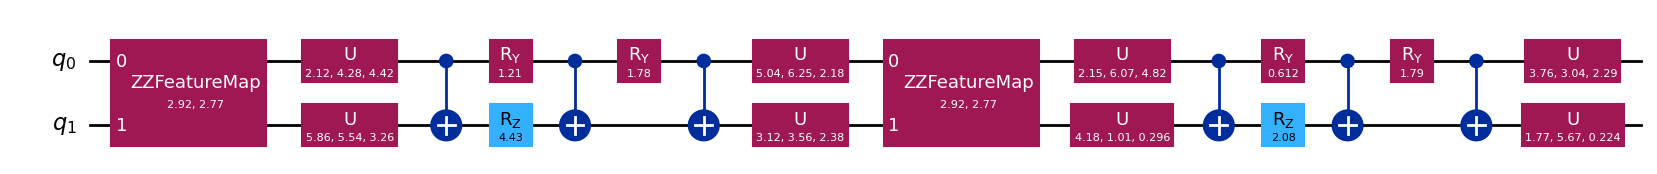

In [119]:
# Test the circuit
# --- Parameters and execution ---
n_qubits = 2
zz_layers = 1
pqc_layers = 1
rep = 2

# Input feature and theta vector
x = np.random.uniform(0, np.pi, n_qubits)
n_blocks = pqc_layers * n_qubits
theta = np.random.uniform(0, 2 * np.pi, n_blocks * 15)

# Build and plot
qc = build_circuit(n_qubits, zz_layers, x, theta, rep)
qc.draw("mpl")

In [120]:
# Estimator
sv_estimator = StatevectorEstimator()

# Prediction: sigmoid(<ZI>) gives probability of class 0
def predict(theta, x):
    qc = build_circuit(n_qubits=2, zz_layers=1, x=x, theta=theta, rep=2)
    obs = Pauli("ZI")
    job = sv_estimator.run([(qc, obs)])
    result = job.result()[0]
    value = result.data.evs
    return (1+value)/2  # probability of class 0

# Loss: binary cross-entropy
def compute_loss(theta):
    preds = np.array([predict(theta, x) for x in X_train])
    return log_loss(Y_train, preds, labels=[0, 1])

# Iris data classification

In [121]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

# Load full Iris dataset
iris = load_iris()
X_all = iris.data
y_all = iris.target  # 0 = Setosa, 1 = Versicolor, 2 = Virginica

# Reduce to 2 features (PCA or select manually)
X_pca = PCA(n_components=2).fit_transform(X_all)

# Rescale features to [0, 2π]
X_scaled = MinMaxScaler((0, np.pi)).fit_transform(X_pca)

# Split by class
X0 = X_scaled[y_all == 0]  # class 0
X1 = X_scaled[y_all == 1]  # class 1
X2 = X_scaled[y_all == 2]  # class 2

In [122]:
# Choose two classes to classify (e.g., class 0 vs class 2)
X_class0 = X0
X_class1 = X2

# Stack and label
X = np.vstack([X_class0, X_class1])
Y = np.concatenate([
    np.zeros(len(X_class0), dtype=int),  # label 0
    np.ones(len(X_class1), dtype=int)    # label 1
])

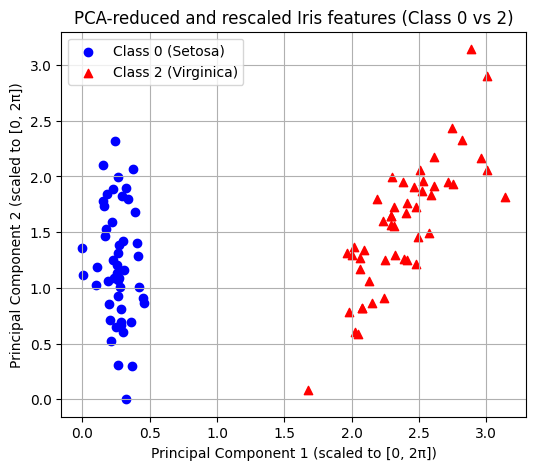

In [123]:
plt.figure(figsize=(6, 5))
plt.scatter(X0[:, 0], X1[:, 1], label='Class 0 (Setosa)', marker='o', color='blue')
plt.scatter(X2[:, 0], X2[:, 1], label='Class 2 (Virginica)', marker='^', color='red')

plt.title("PCA-reduced and rescaled Iris features (Class 0 vs 2)")
plt.xlabel("Principal Component 1 (scaled to [0, 2π])")
plt.ylabel("Principal Component 2 (scaled to [0, 2π])")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=42, shuffle=True)

In [125]:
# Initial parameters: 15 parameters for one SU(4) block
theta_init = np.random.uniform(0, np.pi, 30)

loss_history = []

def wrapped_loss(theta):
    loss = compute_loss(theta)
    loss_history.append(loss)
    return loss

# Train using COBYLA
res = minimize(
    wrapped_loss,
    theta_init,
    method='COBYLA',
    options={'maxiter': 400}
)

theta_opt = res.x

capi_return is NULL
Call-back cb_calcfc_in__cobyla__user__routines failed.


KeyboardInterrupt: 

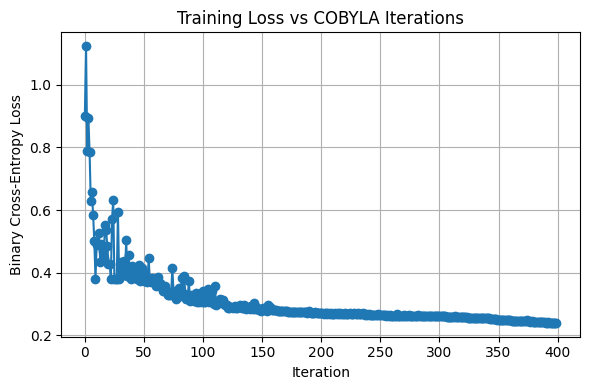

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker='o')
plt.title("Training Loss vs COBYLA Iterations")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on test set
pred_probs = np.array([predict(theta_opt, x) for x in X_test])
pred_labels = (pred_probs >= 0.5).astype(int)
accuracy = accuracy_score(Y_test, pred_labels)

# Output
print("Test accuracy:", accuracy)
# print("Predicted probabilities:", pred_probs)
# print("Predicted labels:", pred_labels)
# print("True labels:", Y_test)

Test accuracy: 0.925


# Run on ibm_yonsei

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp

In [ ]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="<YOUR_API_TOKEN>", 
    # instance="ibm-q-yonsei/internal/default", # from quantum.ibm.com/settings
    instance="yonsei-dedicated/researchyonsei/d-parklab", # from quantum.ibm.com/settings
    overwrite=True
)

In [ ]:
service = QiskitRuntimeService(channel="ibm_quantum")

/var/folders/th/01psyg4s681dx19tj7w_pbfw0000gn/T/ipykernel_12605/1146593203.py:1: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud" and "local" will be the only valid channels. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService(channel="ibm_quantum")


In [ ]:
backend = service.backend("ibm_yonsei")
print(backend.name, backend.status())


ibm_yonsei <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x199389120>


In [ ]:
q_estimator = Estimator(mode=backend)

### New estimator that works with the real quantum device

In [ ]:
def transpile_for_backend(qc, backend):
    return transpile(qc, backend=backend, optimization_level=1)

def q_predict(theta, x):
    qc = build_circuit(n_qubits=2, zz_layers=1, x=x, theta=theta, rep=2)
    qc = transpile_for_backend(qc, backend)  # <- this line is critical
    #obs = Pauli("ZI")
    obs = SparsePauliOp.from_list([("ZI", 1)])
    obs = obs.apply_layout(qc.layout)
    job = q_estimator.run([(qc, obs)])
    result = job.result()[0]
    value = result.data.evs
    return (1 + value) / 2

# Loss: binary cross-entropy
def q_compute_loss(theta):
    preds = np.array([q_predict(theta, x) for x in X_train])
    return log_loss(Y_train, preds, labels=[0, 1])

In [ ]:
# Initial parameters: 15 parameters for one SU(4) block
theta_init = np.random.uniform(0, np.pi, 30)

loss_history = []

def q_wrapped_loss(theta):
    loss = q_compute_loss(theta)
    loss_history.append(loss)
    return loss

# Train using COBYLA
res = minimize(
    q_wrapped_loss,
    theta_init,
    method='COBYLA',
    options={'maxiter': 100}
)

theta_opt = res.x

KeyboardInterrupt: 